In [1]:
!pip install -q kaggle

In [2]:
from google.colab import files

uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [3]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)

!cp kaggle.json /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

In [4]:
!kaggle datasets list -s leapgestrecog

ref                                                                title                                                   size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------------  ------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
gti-upm/leapgestrecog                                              Hand Gesture Recognition Database                 2286085038  2018-07-30 06:43:29.133000          44756        697  0.75             
mrayyanshehzad/ryn-hgd-webcam-hand-gesture-dataset-grayscale       RYN-HGD: Webcam Hand Gesture Dataset (Grayscale)    77267077  2025-12-30 15:55:44.833000            127          1  0.8125           
ryanbijujoseph/hand-gesture-dataset                                hand gesture dataset                               988046106  2026-04-25 21:25:25.860000             28          0  0.5625       

In [5]:
!kaggle datasets download -d gti-upm/leapgestrecog

Dataset URL: https://www.kaggle.com/datasets/gti-upm/leapgestrecog
License(s): CC-BY-NC-SA-4.0
100% 2.13G/2.13G [00:17<00:00, 134MB/s]



In [6]:
!kaggle datasets download -d gti-upm/leapgestrecog

Dataset URL: https://www.kaggle.com/datasets/gti-upm/leapgestrecog
License(s): CC-BY-NC-SA-4.0
leapgestrecog.zip: Skipping, found more recently modified local copy (use --force to force download)


In [7]:
!unzip -q leapgestrecog.zip -d /content/leapgestrecog

In [8]:
import os

base_path = "/content/leapgestrecog"
print(os.listdir(base_path))

['leapGestRecog', 'leapgestrecog']


In [9]:
import os

for root, dirs, files in os.walk(base_path):
    if files:
        print(root, "->", len(files), "files")

/content/leapgestrecog/leapGestRecog/05/07_ok -> 200 files
/content/leapgestrecog/leapGestRecog/05/10_down -> 200 files
/content/leapgestrecog/leapGestRecog/05/05_thumb -> 200 files
/content/leapgestrecog/leapGestRecog/05/03_fist -> 200 files
/content/leapgestrecog/leapGestRecog/05/02_l -> 200 files
/content/leapgestrecog/leapGestRecog/05/04_fist_moved -> 200 files
/content/leapgestrecog/leapGestRecog/05/01_palm -> 200 files
/content/leapgestrecog/leapGestRecog/05/08_palm_moved -> 200 files
/content/leapgestrecog/leapGestRecog/05/09_c -> 200 files
/content/leapgestrecog/leapGestRecog/05/06_index -> 200 files
/content/leapgestrecog/leapGestRecog/09/07_ok -> 200 files
/content/leapgestrecog/leapGestRecog/09/10_down -> 200 files
/content/leapgestrecog/leapGestRecog/09/05_thumb -> 200 files
/content/leapgestrecog/leapGestRecog/09/03_fist -> 200 files
/content/leapgestrecog/leapGestRecog/09/02_l -> 200 files
/content/leapgestrecog/leapGestRecog/09/04_fist_moved -> 200 files
/content/leapges

In [10]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split

DATA_DIR = "/content/leapgestrecog/leapGestRecog"

IMG_SIZE = 64
MAX_IMAGES_PER_CLASS = 1000

X = []
y = []

classes = sorted(os.listdir(DATA_DIR))

print("Classes:", classes)

for label, gesture in enumerate(classes):
    gesture_path = os.path.join(DATA_DIR, gesture)

    if not os.path.isdir(gesture_path):
        continue

    count = 0

    for subject in os.listdir(gesture_path):
        subject_path = os.path.join(gesture_path, subject)

        for img_name in os.listdir(subject_path):
            if count >= MAX_IMAGES_PER_CLASS:
                break

            img_path = os.path.join(subject_path, img_name)

            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            if img is not None:
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                X.append(img)
                y.append(label)
                count += 1

        if count >= MAX_IMAGES_PER_CLASS:
            break

    print(f"{gesture}: {count} images")

X = np.array(X, dtype=np.float32) / 255.0
y = np.array(y)

X = X.reshape(-1, IMG_SIZE, IMG_SIZE, 1)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Classes: ['00', '01', '02', '03', '04', '05', '06', '07', '08', '09']
00: 1000 images
01: 1000 images
02: 1000 images
03: 1000 images
04: 1000 images
05: 1000 images
06: 1000 images
07: 1000 images
08: 1000 images
09: 1000 images

X shape: (10000, 64, 64, 1)
y shape: (10000,)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Testing set:", X_test.shape, y_test.shape)

Training set: (8000, 64, 64, 1) (8000,)
Validation set: (1000, 64, 64, 1) (1000,)
Testing set: (1000, 64, 64, 1) (1000,)


In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(64, 64, 1)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,914 (2.61 MB)

 Trainable params: 683,914 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.6614 - loss: 0.9677 - val_accuracy: 0.9920 - val_loss: 0.0486 - learning_rate: 0.0010
Epoch 2/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9578 - loss: 0.1261 - val_accuracy: 0.9990 - val_loss: 0.0092 - learning_rate: 0.0010
Epoch 3/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9789 - loss: 0.0626 - val_accuracy: 0.9990 - val_loss: 0.0025 - learning_rate: 0.0010
Epoch 4/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9809 - loss: 0.0527 - val_accuracy: 1.0000 - val_loss: 0.0014 - learning_rate: 0.0010
Epoch 5/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9889 - loss: 0.0330 - val_accuracy: 1.0000 - val_loss: 6.3008e-04 - learning_rate: 0.0010
Epoch 6/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9879 - loss: 0.0316 - val_accuracy: 1.0000 - val_loss: 0.0012 - learning_rate: 0.0010
Epoch 7/15
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9884 - loss

In [14]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 1.0000 - loss: 5.3838e-05
Test Loss: 0.0001
Test Accuracy: 1.0000
Test Accuracy: 100.00%


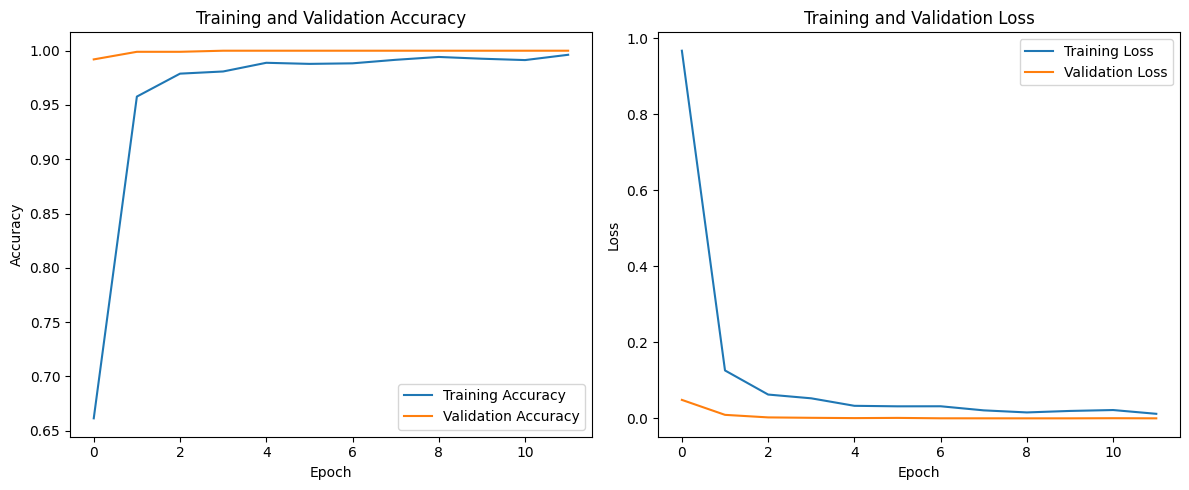

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Classification Report:

              precision    recall  f1-score   support

        Palm       1.00      1.00      1.00       100
           L       1.00      1.00      1.00       100
        Fist       1.00      1.00      1.00       100
  Fist Moved       1.00      1.00      1.00       100
       Thumb       1.00      1.00      1.00       100
       Index       1.00      1.00      1.00       100
          OK       1.00      1.00      1.00       100
  Palm Moved       1.00      1.00      1.00       100
           C       1.00      1.00      1.00       100
        Down       1.00      1.00      1.00       100

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



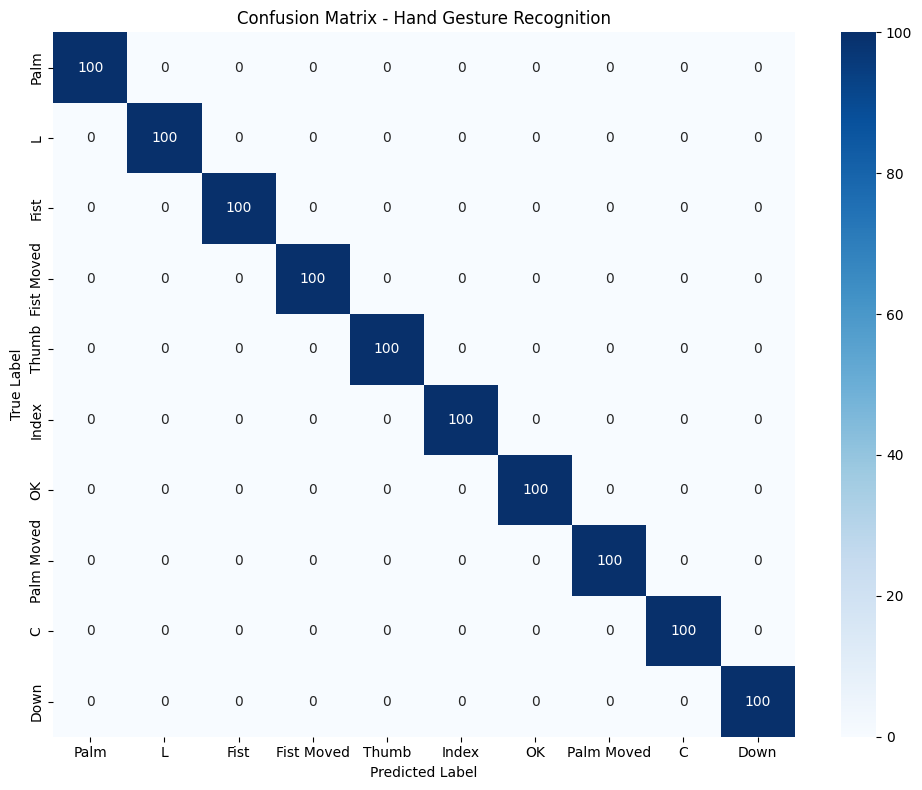

In [16]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predict test images
y_pred_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

# Gesture names
gesture_names = [
    "Palm",
    "L",
    "Fist",
    "Fist Moved",
    "Thumb",
    "Index",
    "OK",
    "Palm Moved",
    "C",
    "Down"
]

# Classification report
print("Classification Report:\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=gesture_names
))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=gesture_names,
    yticklabels=gesture_names
)

plt.title("Confusion Matrix - Hand Gesture Recognition")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

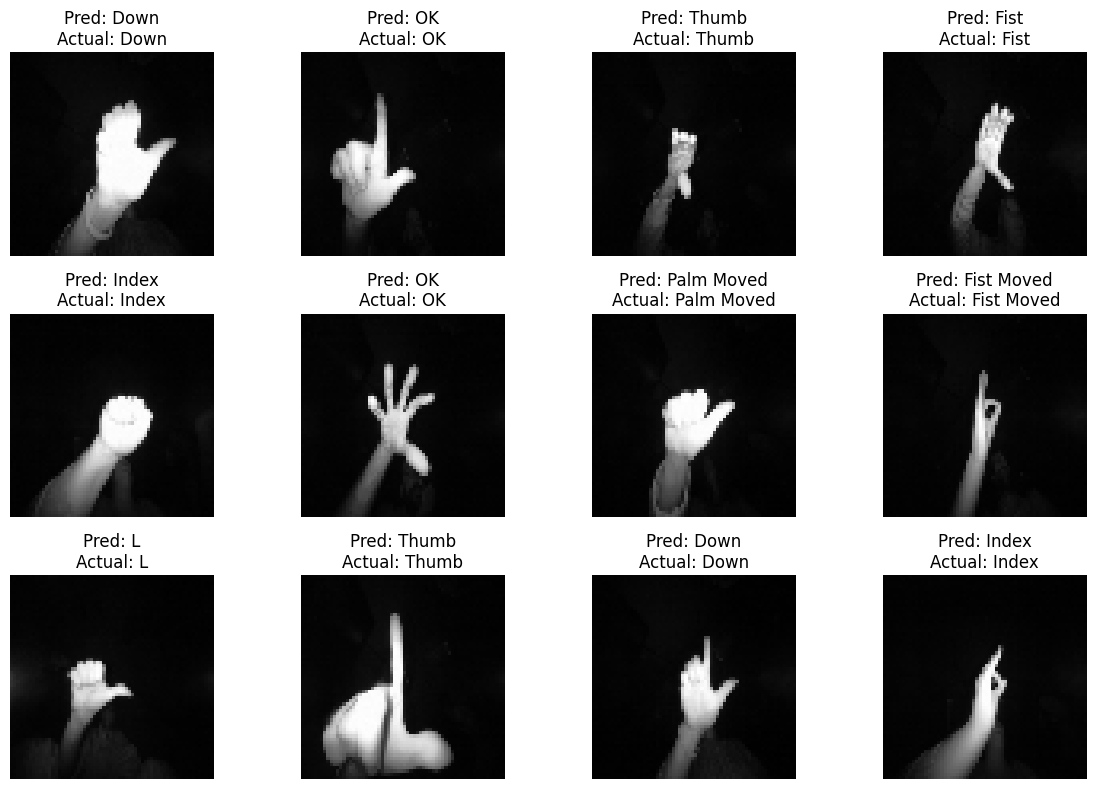

In [17]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)

    plt.imshow(X_test[i].reshape(64, 64), cmap='gray')

    predicted = gesture_names[y_pred[i]]
    actual = gesture_names[y_test[i]]

    plt.title(f"Pred: {predicted}\nActual: {actual}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [18]:
# Save the trained model
model.save("hand_gesture_cnn.keras")

print("Model saved successfully as: hand_gesture_cnn.keras")

Model saved successfully as: hand_gesture_cnn.keras


In [19]:
import os

print("File exists:", os.path.exists("hand_gesture_cnn.keras"))
print("File size:", round(os.path.getsize("hand_gesture_cnn.keras") / (1024 * 1024), 2), "MB")

File exists: True
File size: 7.87 MB


Classification Report:

              precision    recall  f1-score   support

        Palm       1.00      1.00      1.00       100
           L       1.00      1.00      1.00       100
        Fist       1.00      1.00      1.00       100
  Fist Moved       1.00      1.00      1.00       100
       Thumb       1.00      1.00      1.00       100
       Index       1.00      1.00      1.00       100
          OK       1.00      1.00      1.00       100
  Palm Moved       1.00      1.00      1.00       100
           C       1.00      1.00      1.00       100
        Down       1.00      1.00      1.00       100

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



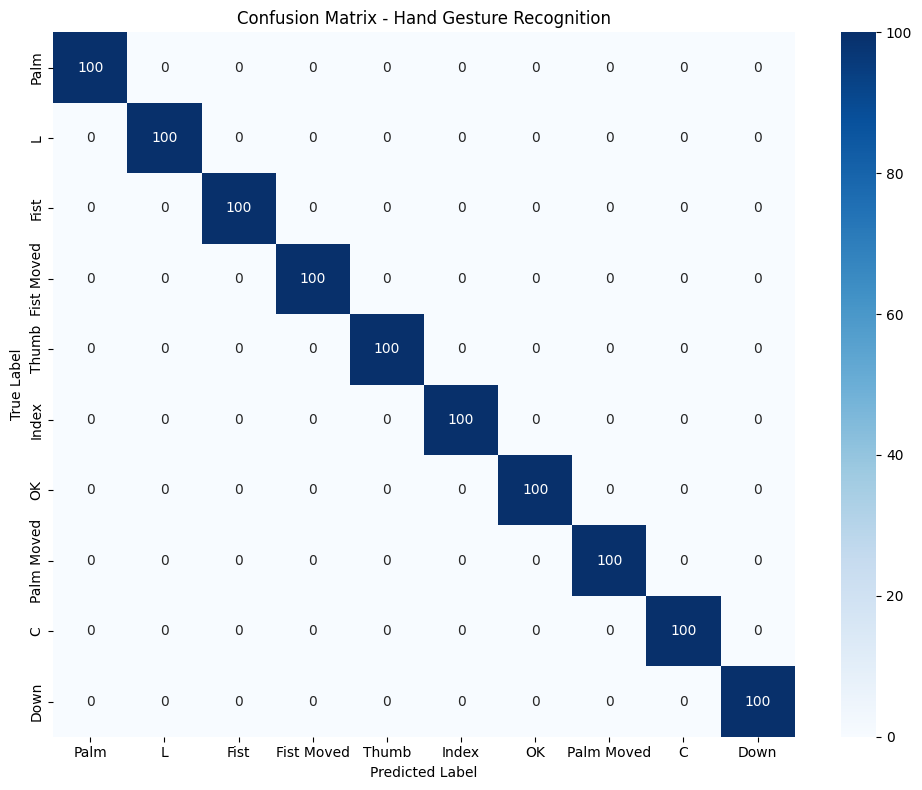

In [20]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Predictions
y_pred_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

# Readable class names
class_names = [
    "Palm",
    "L",
    "Fist",
    "Fist Moved",
    "Thumb",
    "Index",
    "OK",
    "Palm Moved",
    "C",
    "Down"
]

# Classification report
print("Classification Report:\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=class_names
))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Hand Gesture Recognition")
plt.tight_layout()
plt.show()

# Conclusion

This project implements a Convolutional Neural Network (CNN) based hand gesture recognition system using the LeapGestRecog dataset.

The model is trained to classify 10 different hand gestures:

1. Palm
2. L
3. Fist
4. Fist Moved
5. Thumb
6. Index
7. OK
8. Palm Moved
9. C
10. Down

The images were resized to 64×64 pixels and converted to grayscale before being used for training.

The dataset was divided subject-wise into training, validation, and testing sets to evaluate the model on subjects that were not used during training.

The trained CNN model was evaluated using:
- Accuracy
- Classification Report
- Confusion Matrix
- Sample Predictions

The trained model was saved as `hand_gesture_cnn.keras`.

## Conclusion

The developed CNN model can recognize different hand gestures from images and demonstrates the application of deep learning in gesture-based human-computer interaction.

In [21]:
from google.colab import files

files.download("hand_gesture_cnn.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>